# 03 — Result Exploration

Notebook ringkasan semua hasil penelitian:
- T1: Performa klasifikasi (accuracy, F1, confusion matrix, parameter efficiency)
- T2: Analisis SVD dan attention (singular value decay, intruder dimensions, attention entropy)
- T3: Pergeseran CLS embedding (cosine shift, Silhouette/DBI, t-SNE/UMAP, korelasi)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/ahmdzaidan/cassava-lora.git
%cd cassava-lora

Mounted at /content/drive
Cloning into 'cassava-lora'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 135 (delta 36), reused 123 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (135/135), 3.93 MiB | 6.45 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/cassava-lora


In [2]:
# Install Requirements
!pip install -q -r /content/cassava-lora/requirements.txt
!python -c "import torch, transformers, peft; print('OK')"
!python -c "import torch; print('GPU:', torch.cuda.is_available())"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.3.0 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 

In [3]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Image as IPImage

figures_dir = Path('./reports/figures')
tables_dir = Path('./reports/tables')

## T1: Performa Klasifikasi

,model,trainable_params,total_params,trainable_pct,training_time_s,val_loss,val_accuracy,val_f1_macro,val_f1_weighted,val_precision_macro,val_recall_macro,accuracy,f1_macro,params_millions,accuracy_per_M_params,f1_per_M_params,compression_ratio
0,Linear Probe,3845,86393093,0.0045,2105.443251,1.264741,0.479388,0.453021,0.509508,0.548160,0.615784,0.479388,0.453021,0.00,124.6782,117.8207,22468.94
1,Full Fine-tune,86393093,86393093,100.0000,856.426095,0.700911,0.846879,0.803046,0.851014,0.788969,0.823741,0.846879,0.803046,86.39,0.0098,0.0093,1.00
2,LoRA r=4 (qv),151301,86540549,0.1748,632.938853,NaN,0.743227,0.710222,0.754397,0.676403,0.794426,0.743227,0.710222,0.15,4.9122,4.6941,571.98
3,LoRA r=32 (qv),1183493,87572741,1.3514,752.181139,NaN,0.825677,0.779058,0.832679,0.755458,0.818650,0.825677,0.779058,1.18,0.6977,0.6583,74.00
4,LoRA r=16 (qv),593669,86982917,0.6825,753.361420,NaN,0.824499,0.784368,0.834896,0.767650,0.822537,0.824499,0.784368,0.59,1.3888,1.3212,146.52
5,LoRA r=8 (qv),298757,86688005,0.3446,863.826338,NaN,0.772674,0.741975,0.785822,0.716407,0.810855,0.772674,0.741975,0.30,2.5863,2.4835,290.16



fig_T1_accuracy_vs_params.png:


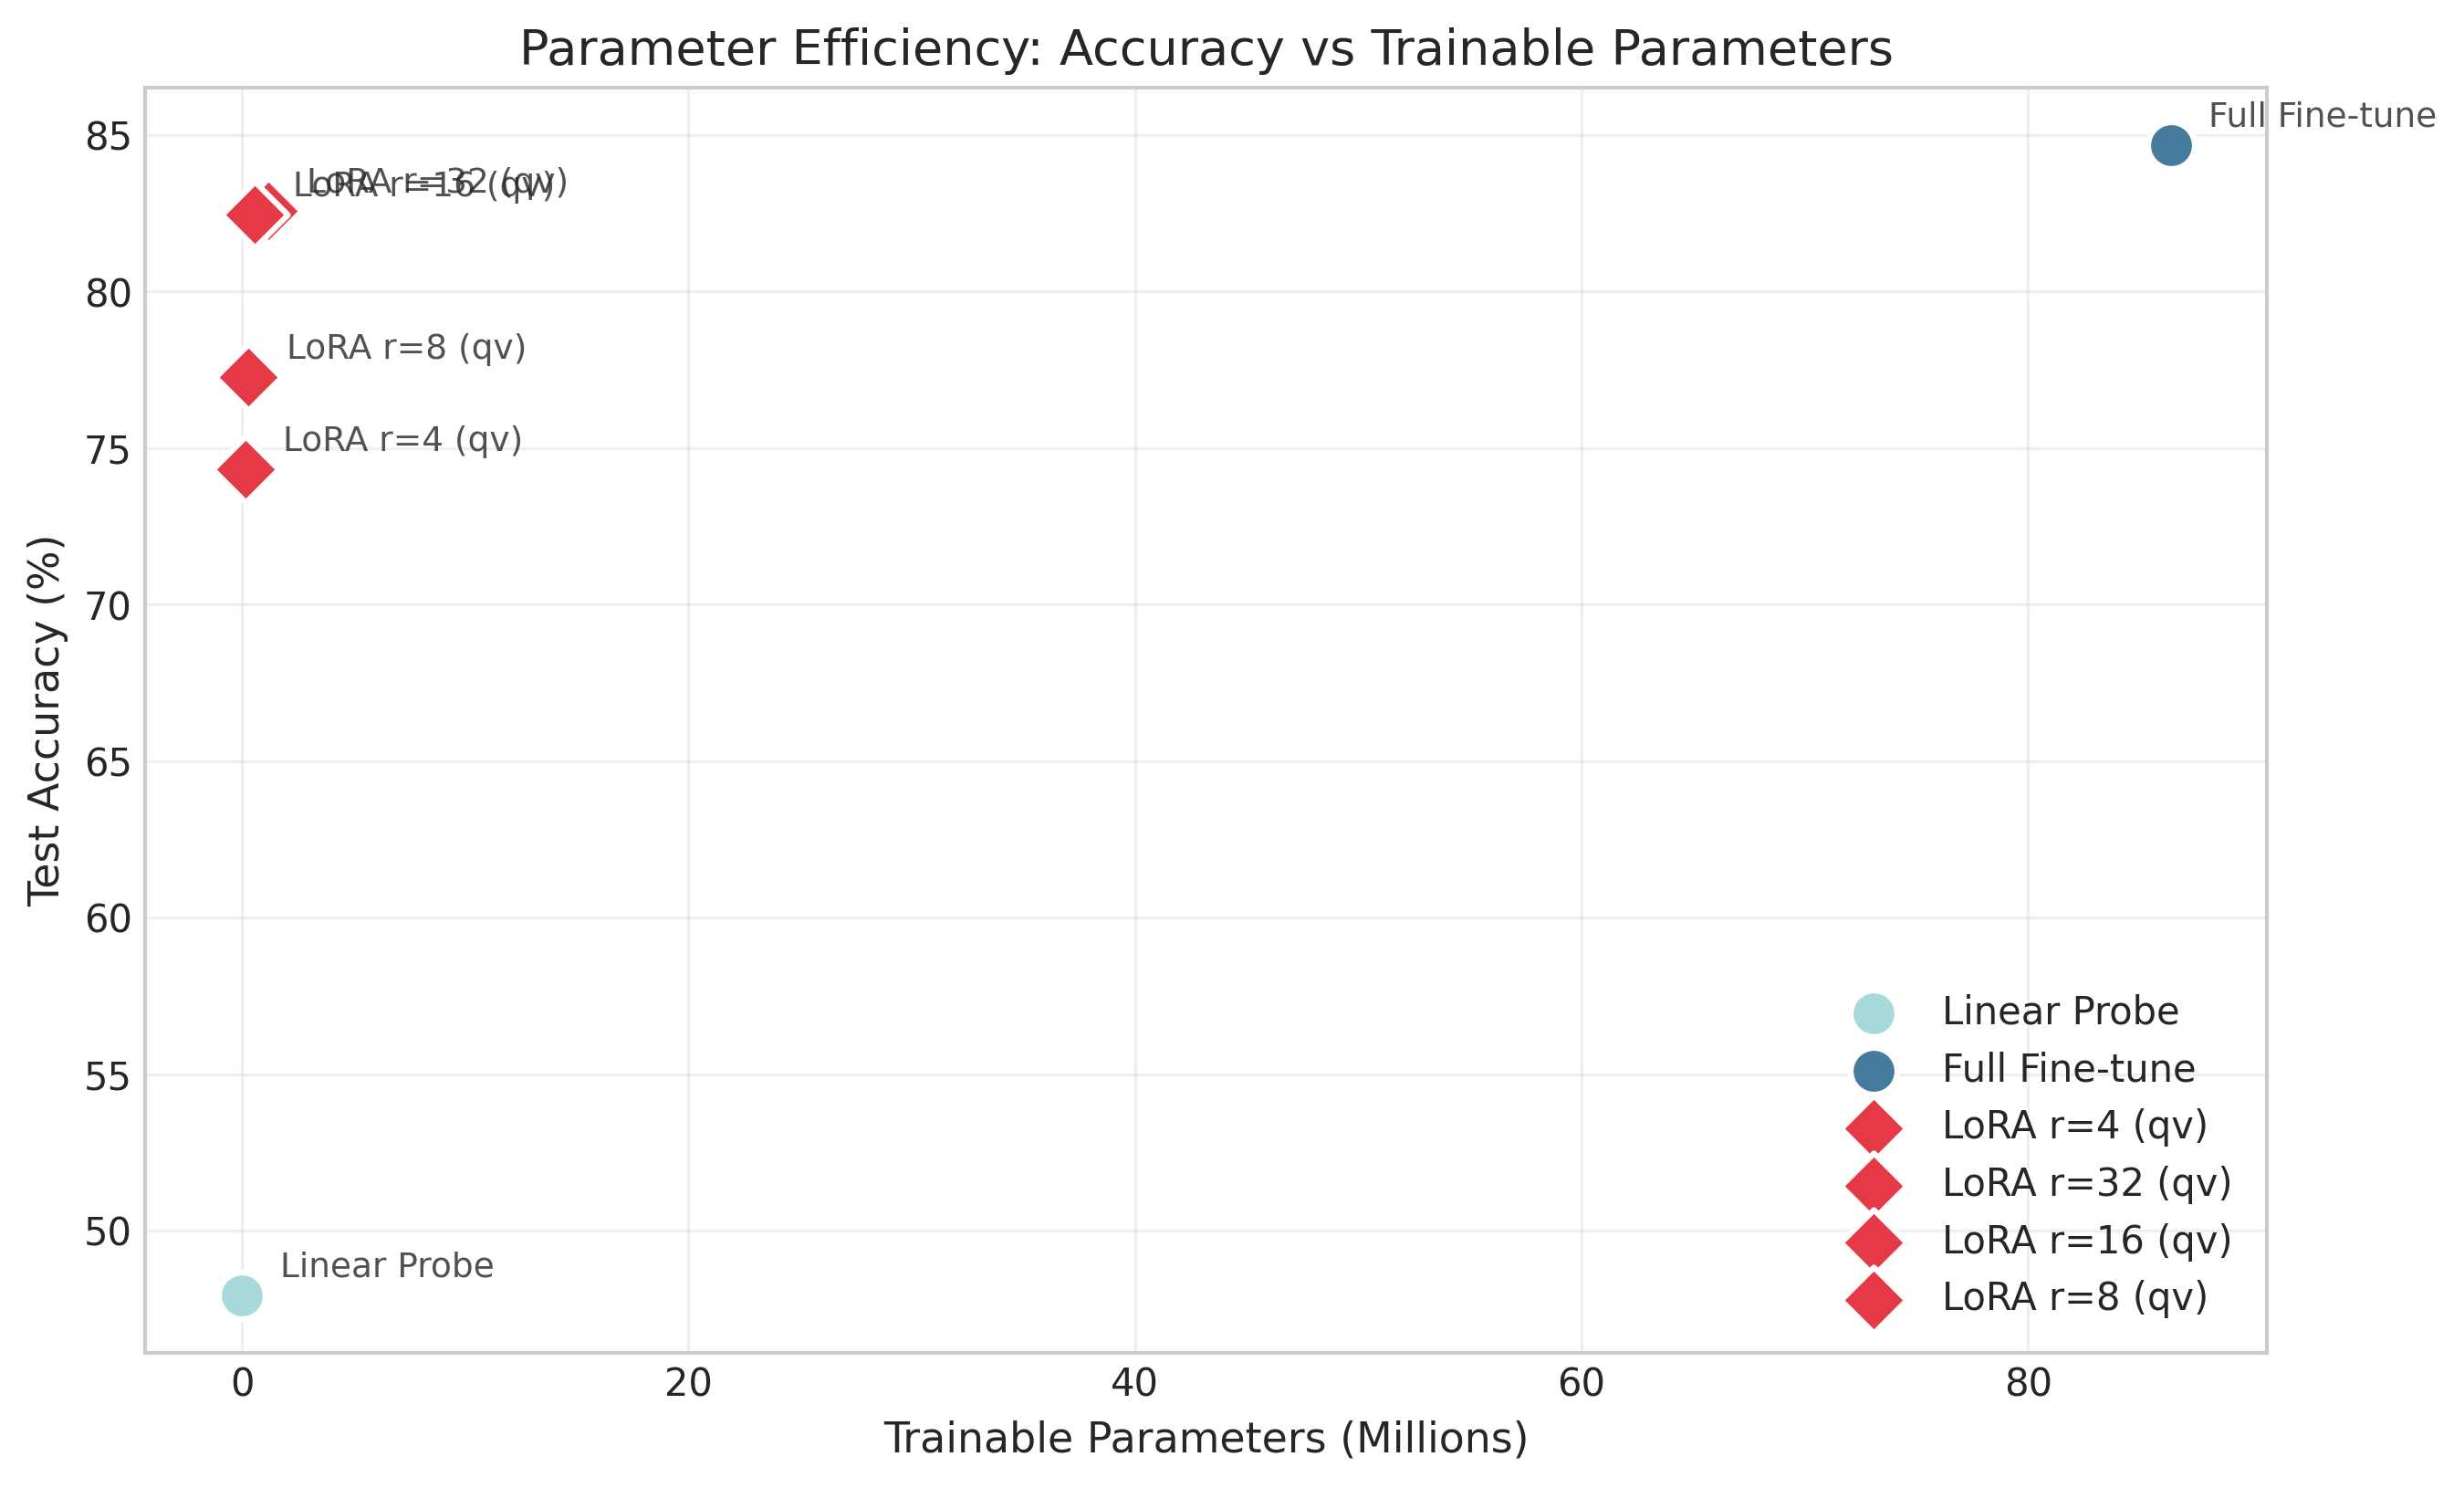


fig_T1_f1_comparison.png:


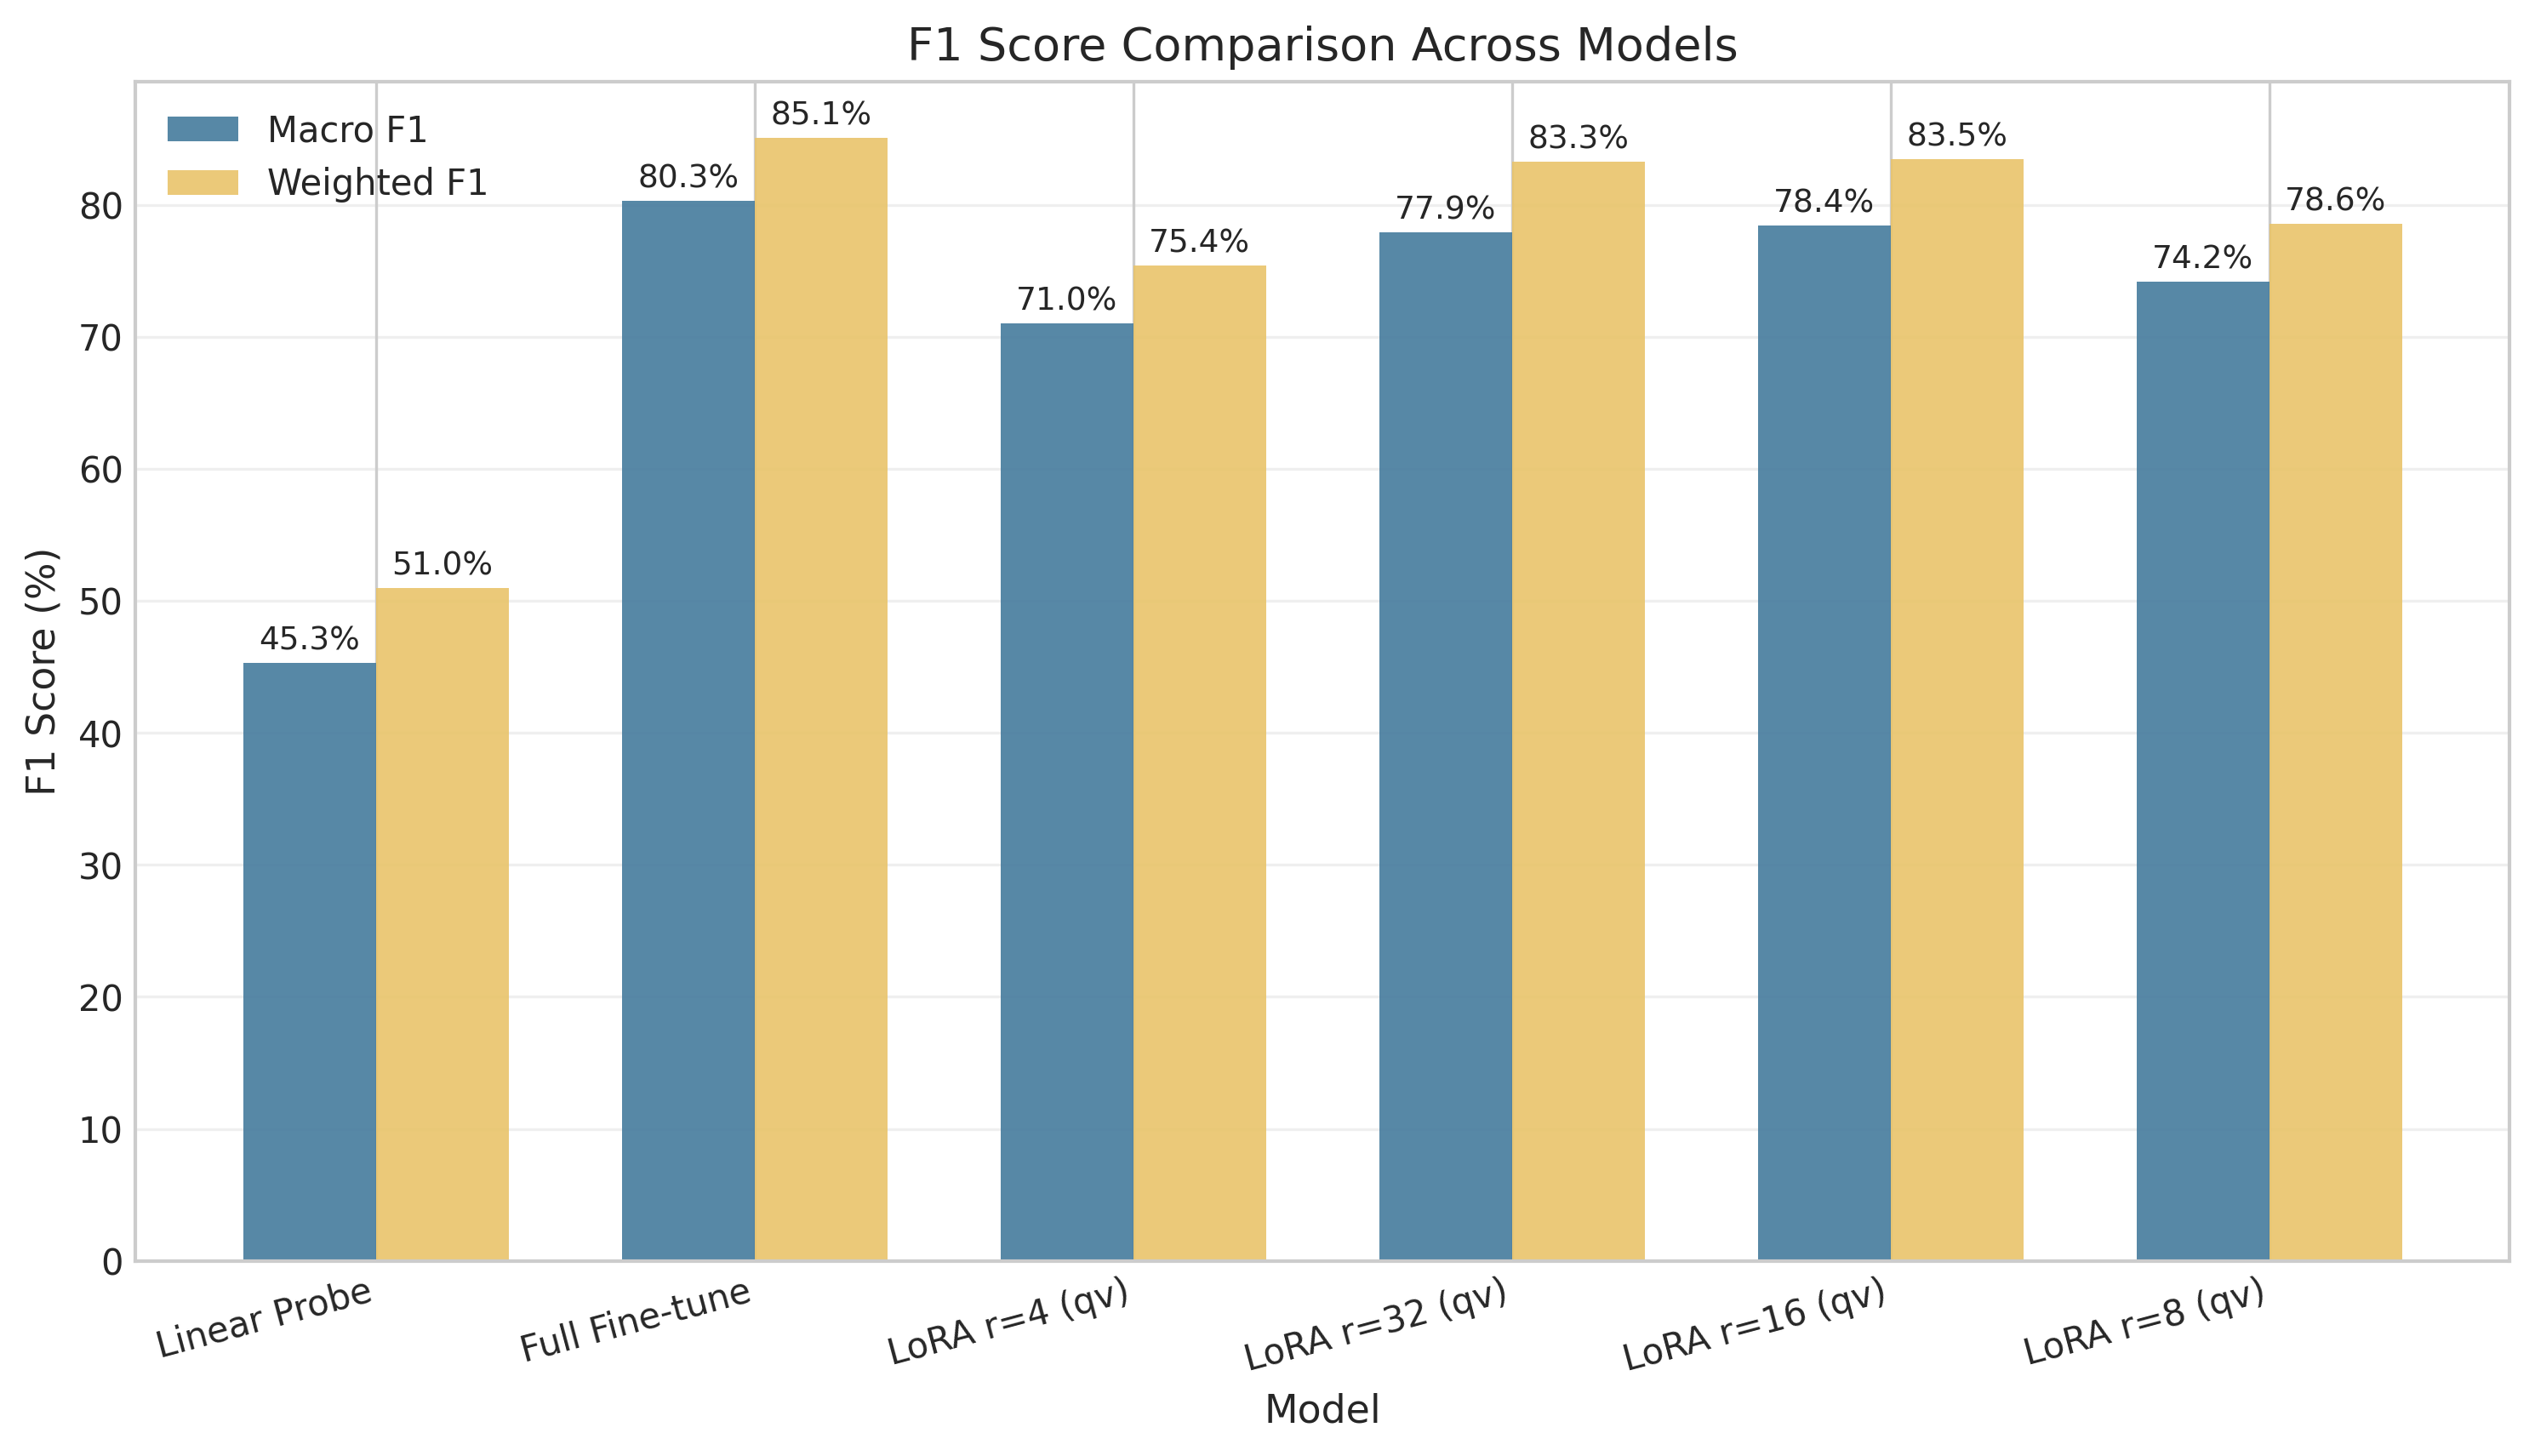

In [4]:
# Tabel perbandingan
comparison_path = tables_dir / 'comparison_T1.csv'
if comparison_path.exists():
    t1_df = pd.read_csv(comparison_path)
    display(t1_df)
else:
    print('T1 results not yet available. Run evaluation first.')

# Display figures
for fig_name in ['fig_T1_accuracy_vs_params.png', 'fig_T1_f1_comparison.png', 'fig_T1_confusion_matrices.png']:
    fig_path = figures_dir / fig_name
    if fig_path.exists():
        print(f'\n{fig_name}:')
        display(IPImage(filename=str(fig_path), width=800))

## T2: Struktur Matriks Embedding/Attention

,layer,effective_rank,frobenius_norm,top_sv,sv_ratio_1_2,num_intruders,avg_cos_sim
0,base_model.model.layers.0.attention.q_proj,2,2.255772,2.240084,13.2460,6,0.1230
1,base_model.model.layers.0.attention.v_proj,3,1.446358,1.356753,2.8331,4,0.1578
2,base_model.model.layers.1.attention.q_proj,2,2.552921,2.449916,3.4738,9,0.0783
3,base_model.model.layers.1.attention.v_proj,2,1.608857,1.567226,4.6708,7,0.0843
4,base_model.model.layers.2.attention.q_proj,2,2.212276,2.183260,6.5826,9,0.0730
5,base_model.model.layers.2.attention.v_proj,4,1.410218,1.313377,2.9455,8,0.0876
6,base_model.model.layers.3.attention.q_proj,3,3.190191,3.077130,3.9928,7,0.0900
7,base_model.model.layers.3.attention.v_proj,5,1.217034,0.893748,1.2745,7,0.0765
8,base_model.model.layers.4.attention.q_proj,2,2.644511,2.627078,13.0474,7,0.0835
9,base_model.model.layers.4.attention.v_proj,6,1.052478,0.837942,1.8178,10,0.0606



fig_T2_svd_decay_per_layer.png:


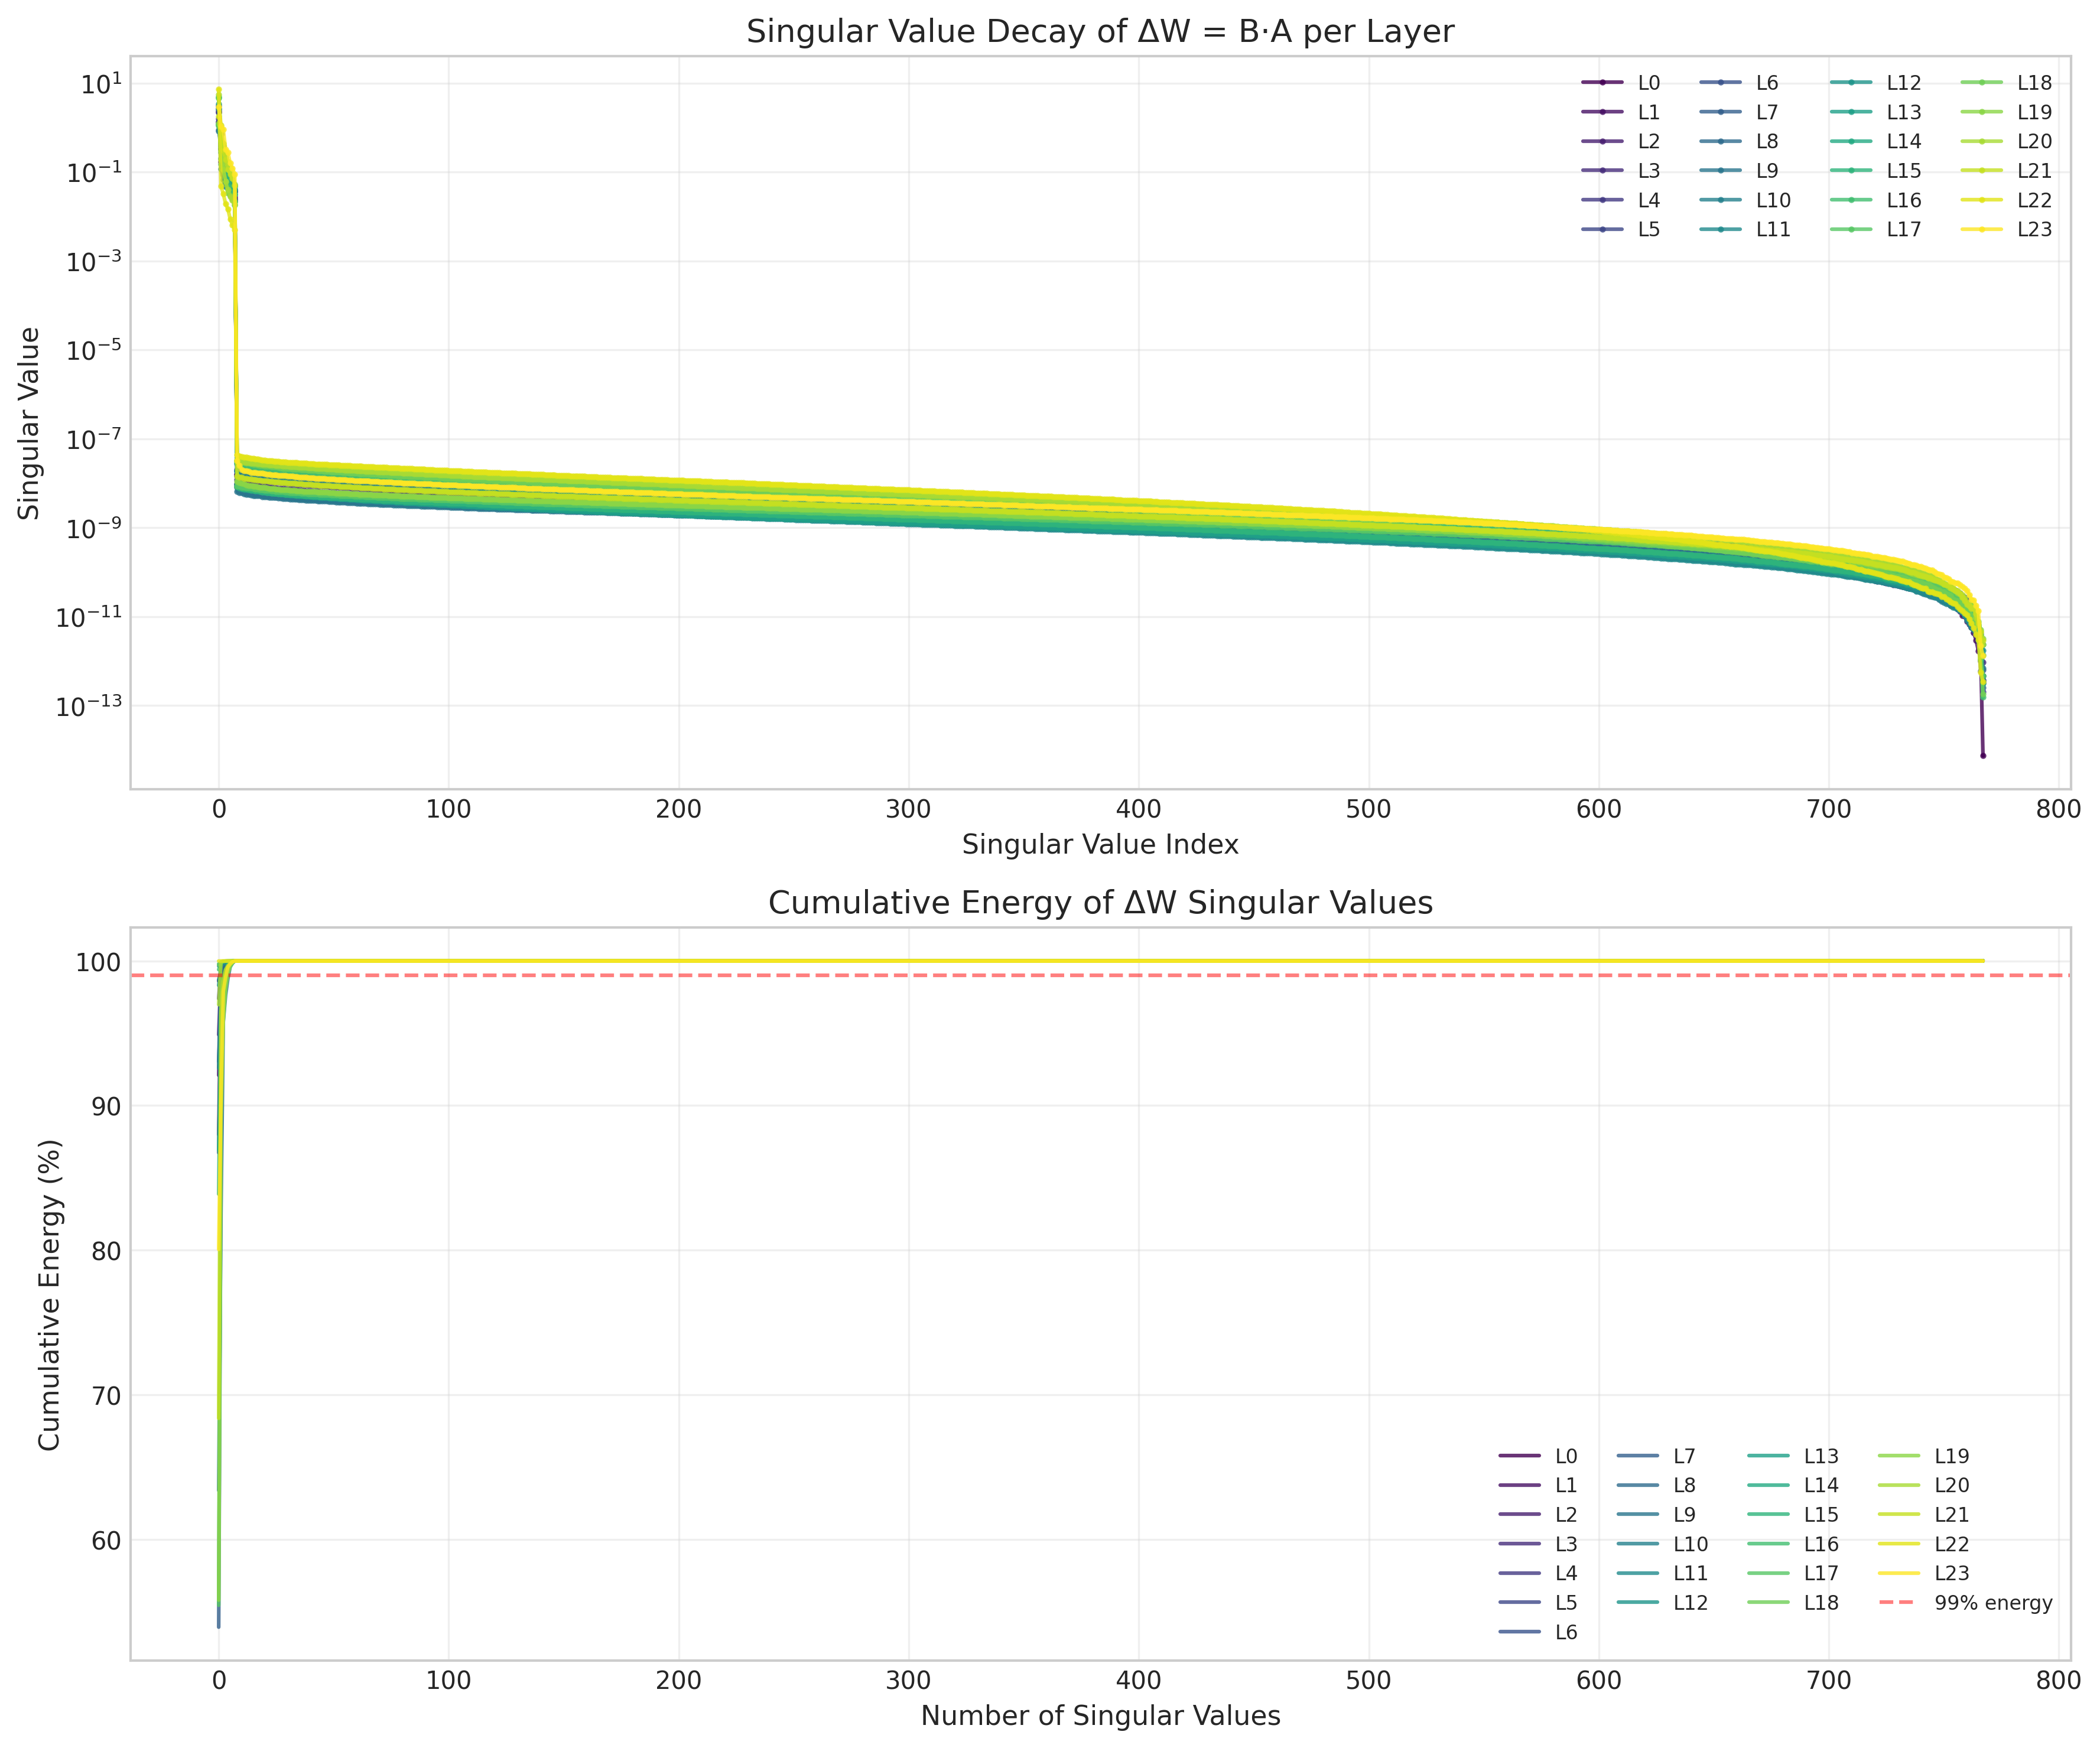


fig_T2_intruder_dimensions.png:


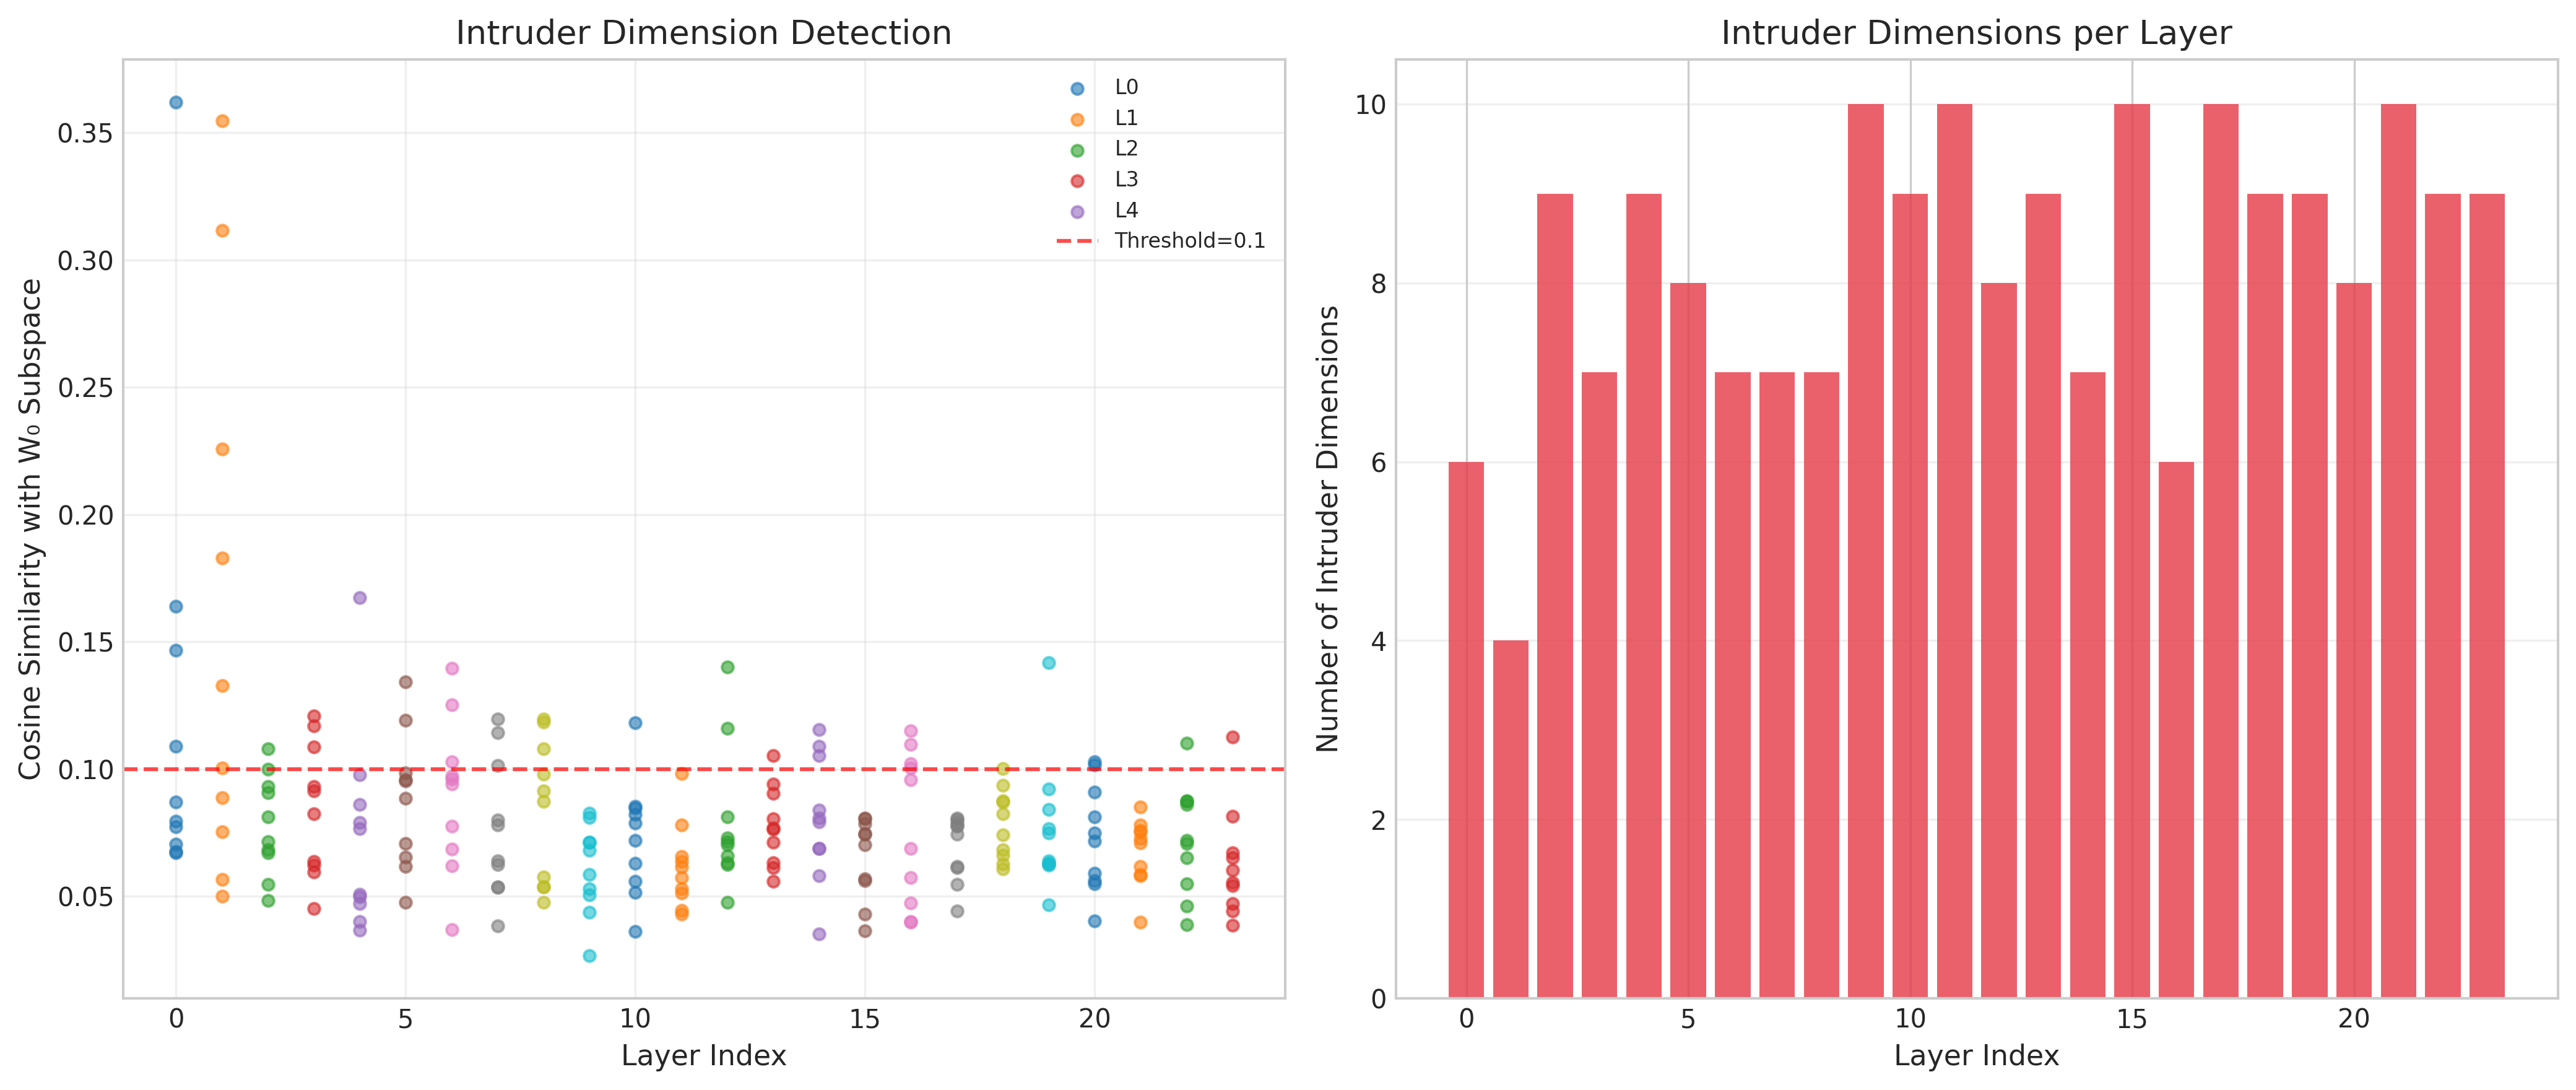


fig_T2_attention_heatmap_comparison.png:


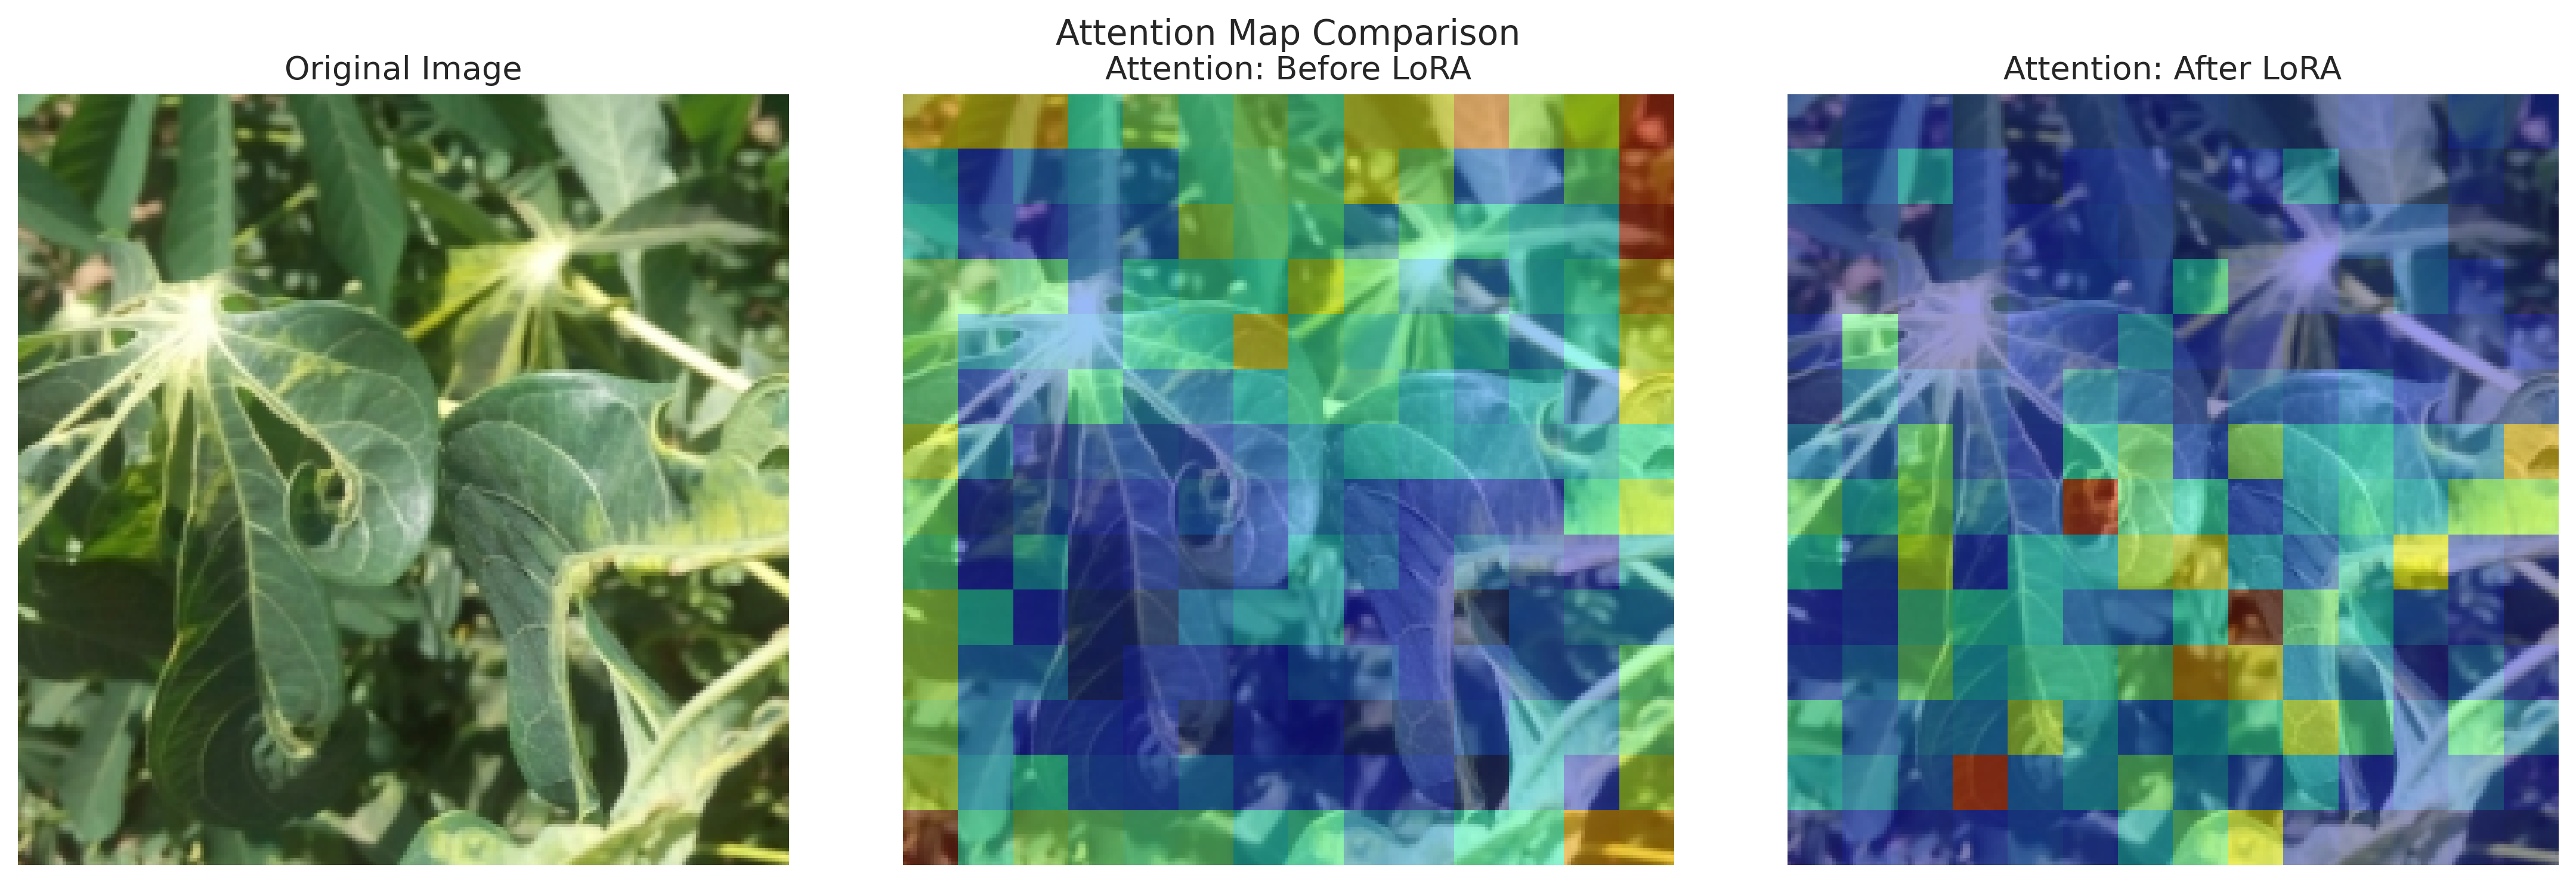


fig_T2_attention_entropy.png:


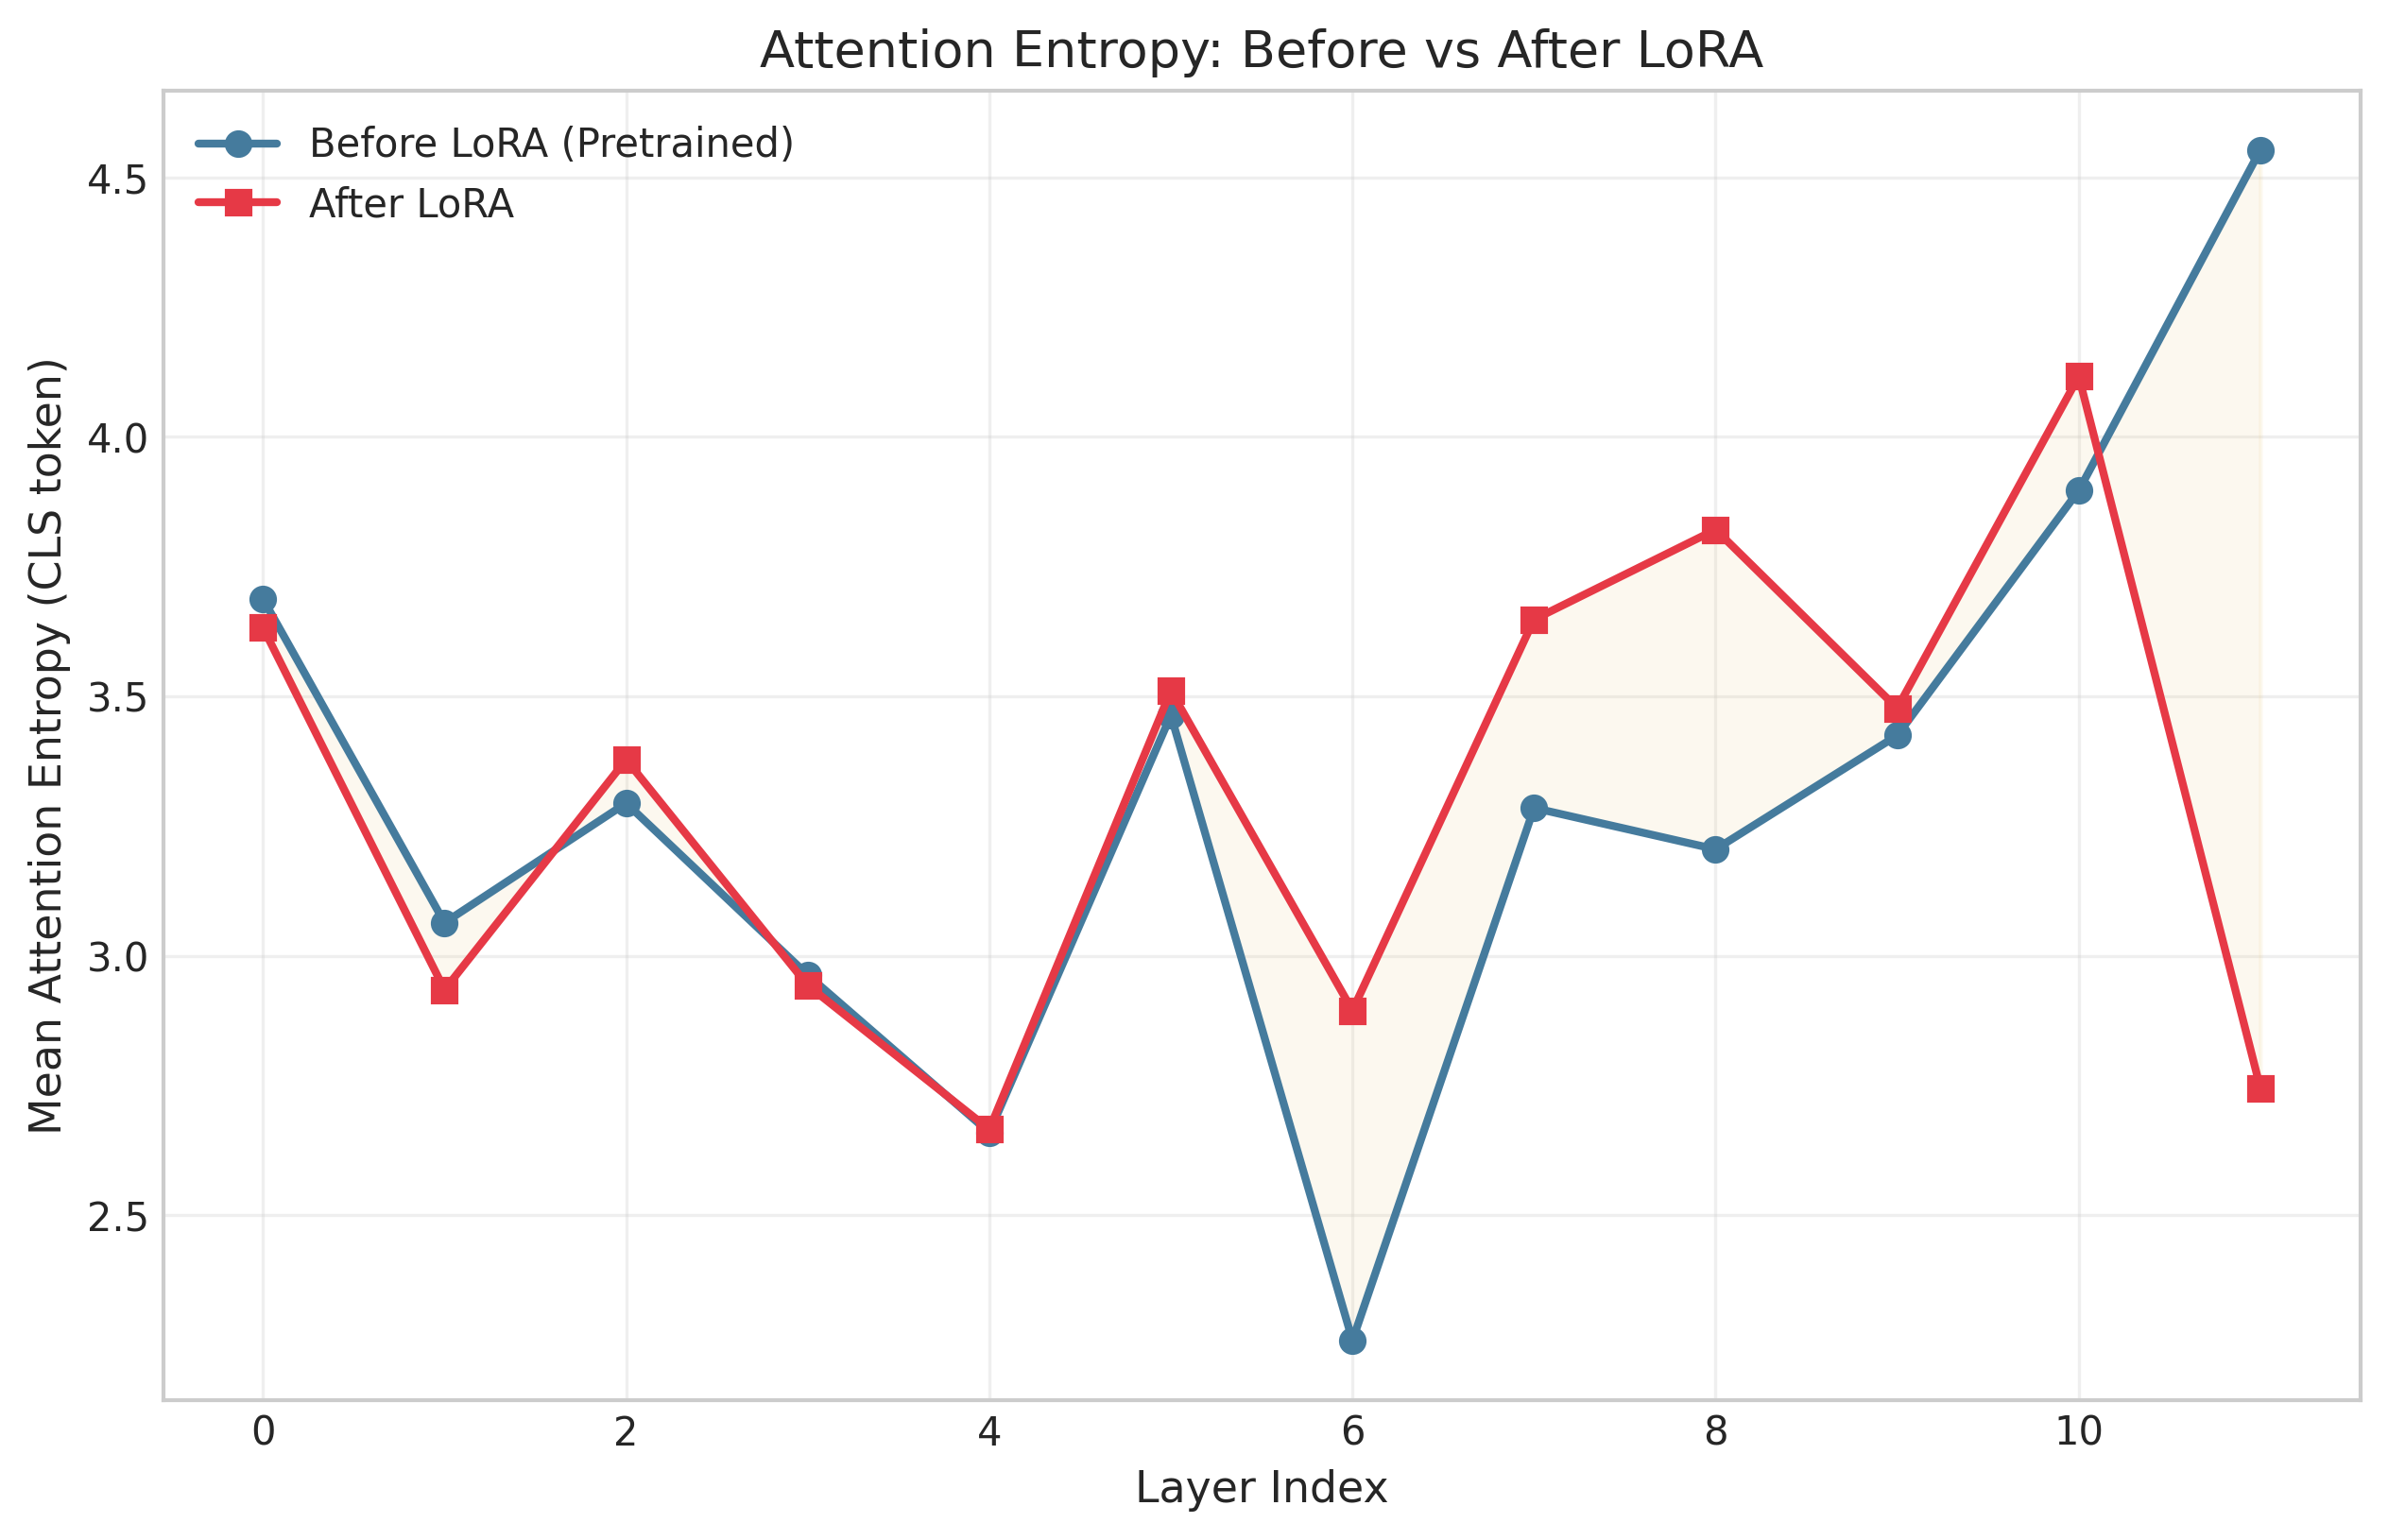

In [5]:
# SVD Summary
svd_path = tables_dir / 'svd_summary.csv'
if svd_path.exists():
    svd_df = pd.read_csv(svd_path)
    display(svd_df)

# Display SVD figures
for fig_name in ['fig_T2_svd_decay_per_layer.png', 'fig_T2_intruder_dimensions.png',
                  'fig_T2_attention_heatmap_comparison.png', 'fig_T2_attention_entropy.png']:
    fig_path = figures_dir / fig_name
    if fig_path.exists():
        print(f'\n{fig_name}:')
        display(IPImage(filename=str(fig_path), width=800))

## T3: Pergeseran Vektor [CLS] & Korelasi

,scope,metric,before_lora,after_lora,change,interpretation
0,Global,Silhouette Score,-0.0044,0.1962,0.2006,Higher is better (max=1)
1,Global,Davies-Bouldin Index,7.9710,1.5193,-6.4517,Lower is better (min=0)



fig_T3_cls_shift_per_layer.png:


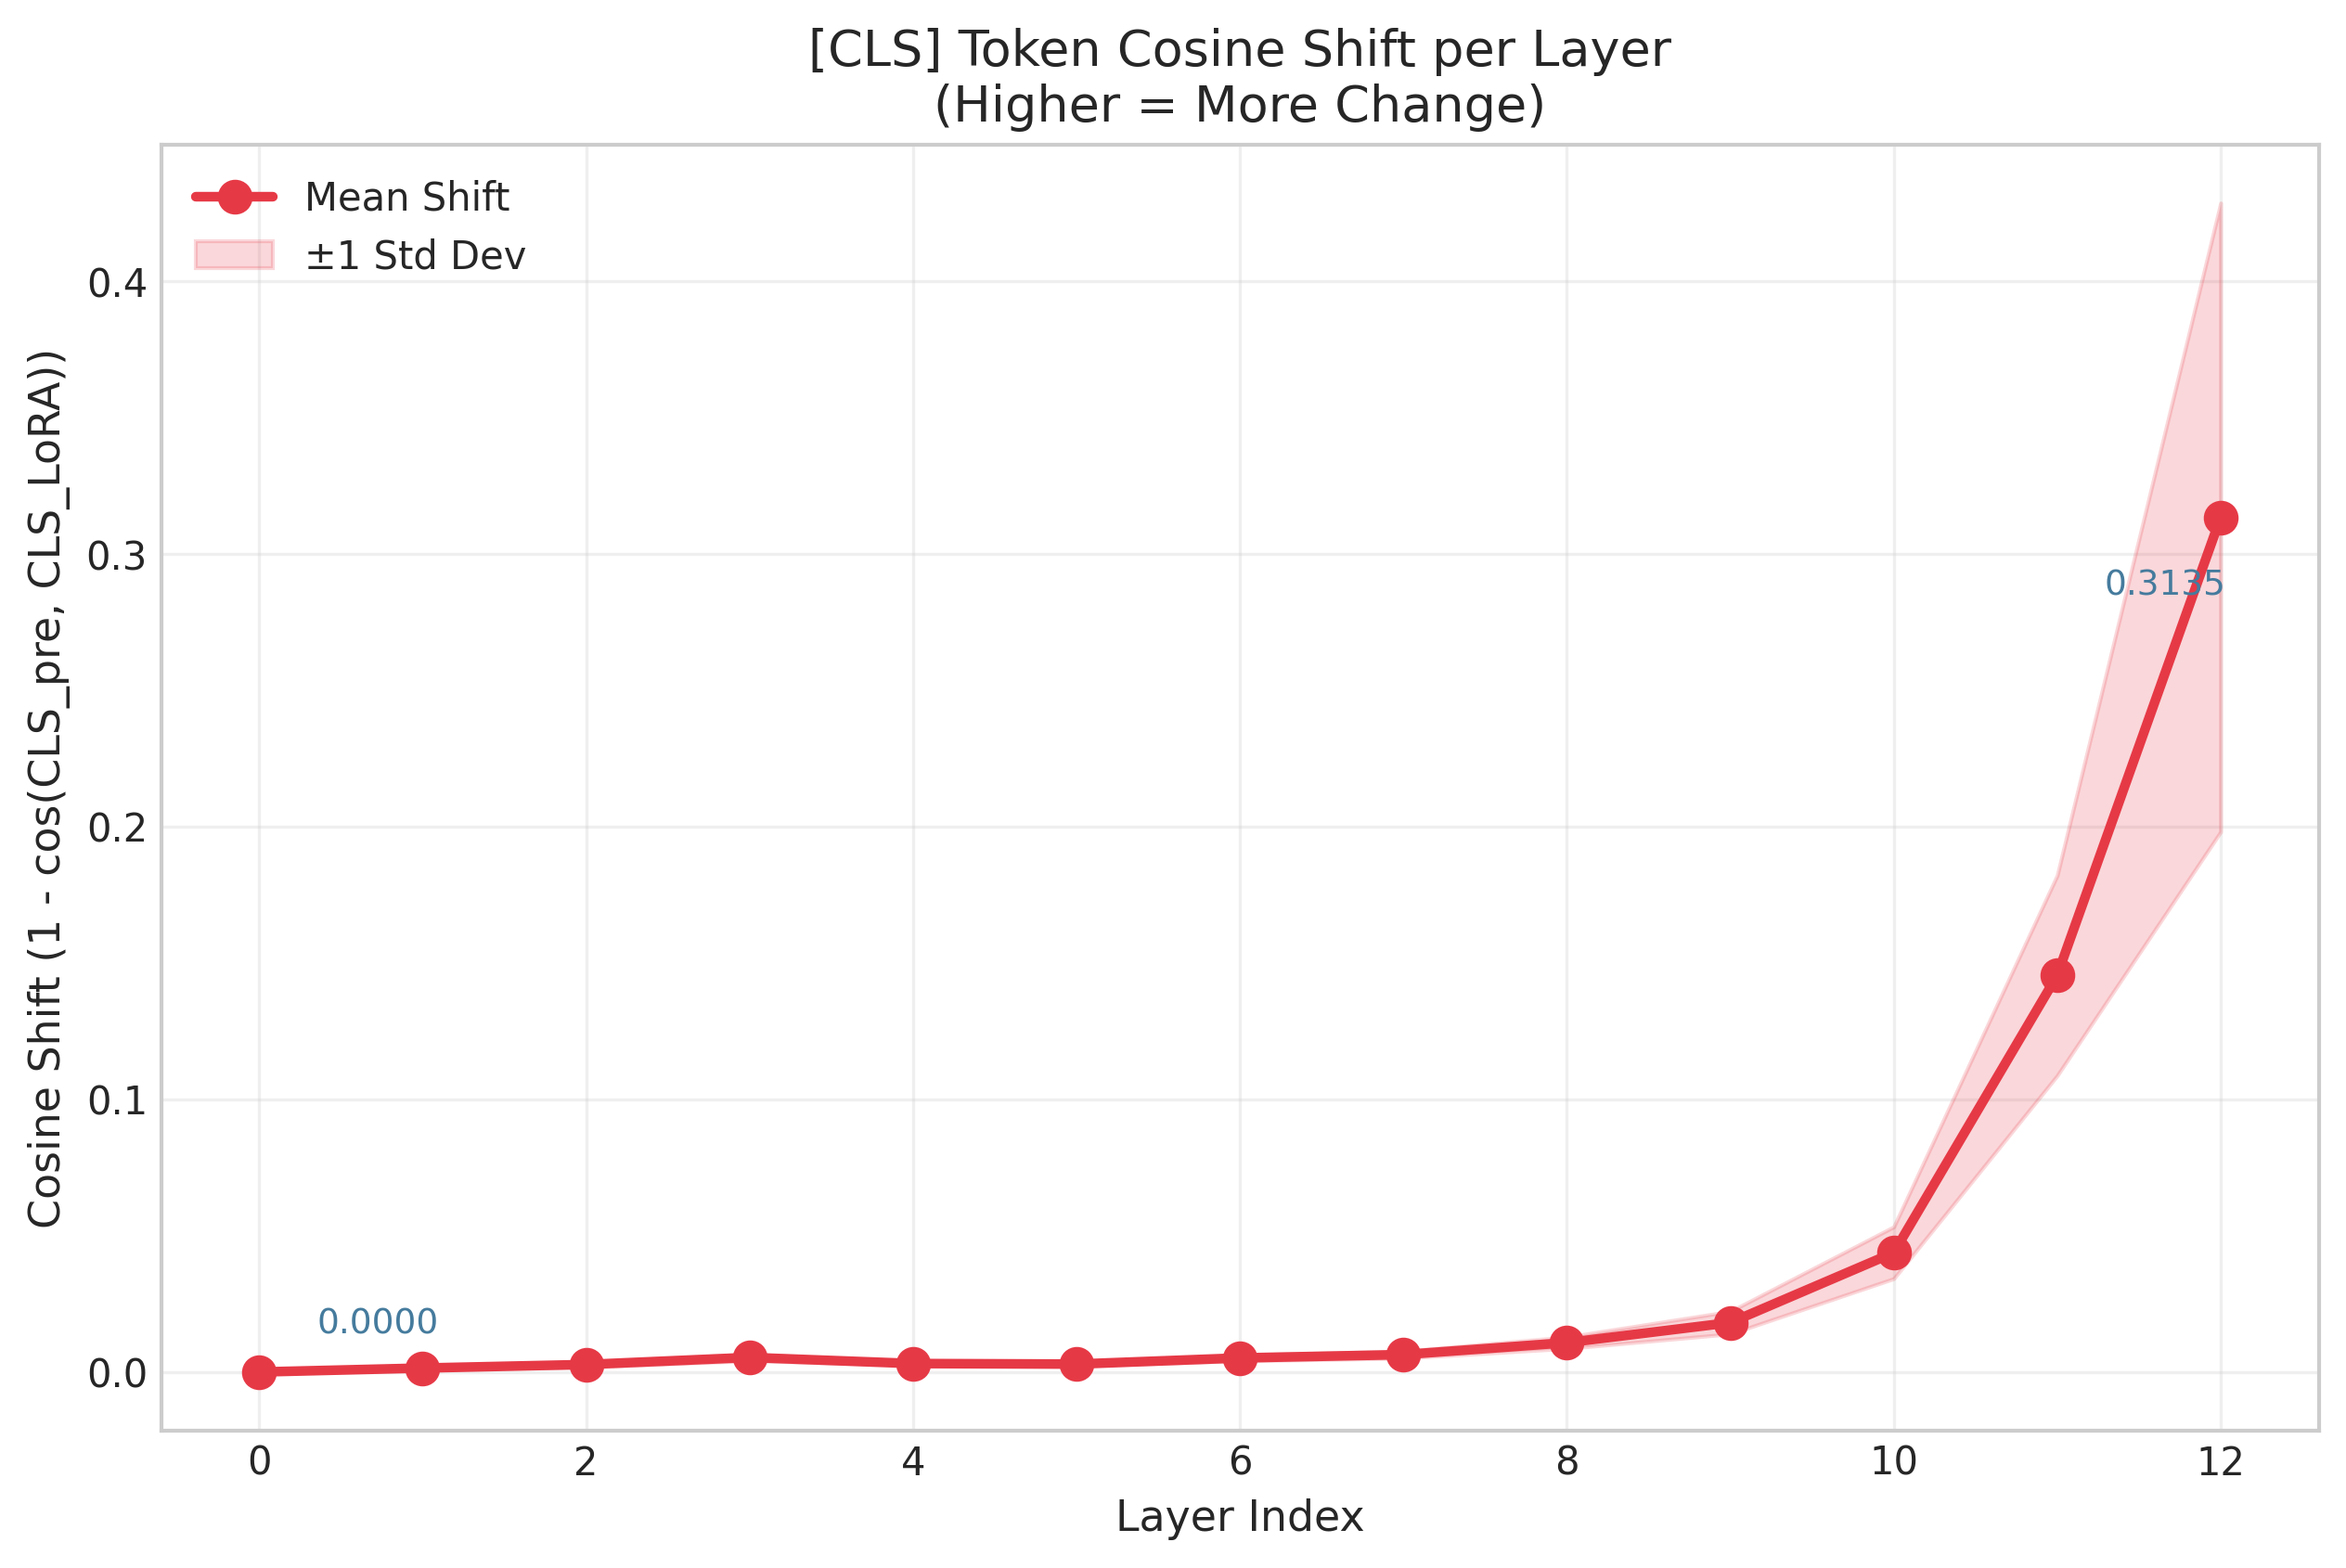


fig_T3_tsne_before_after.png:


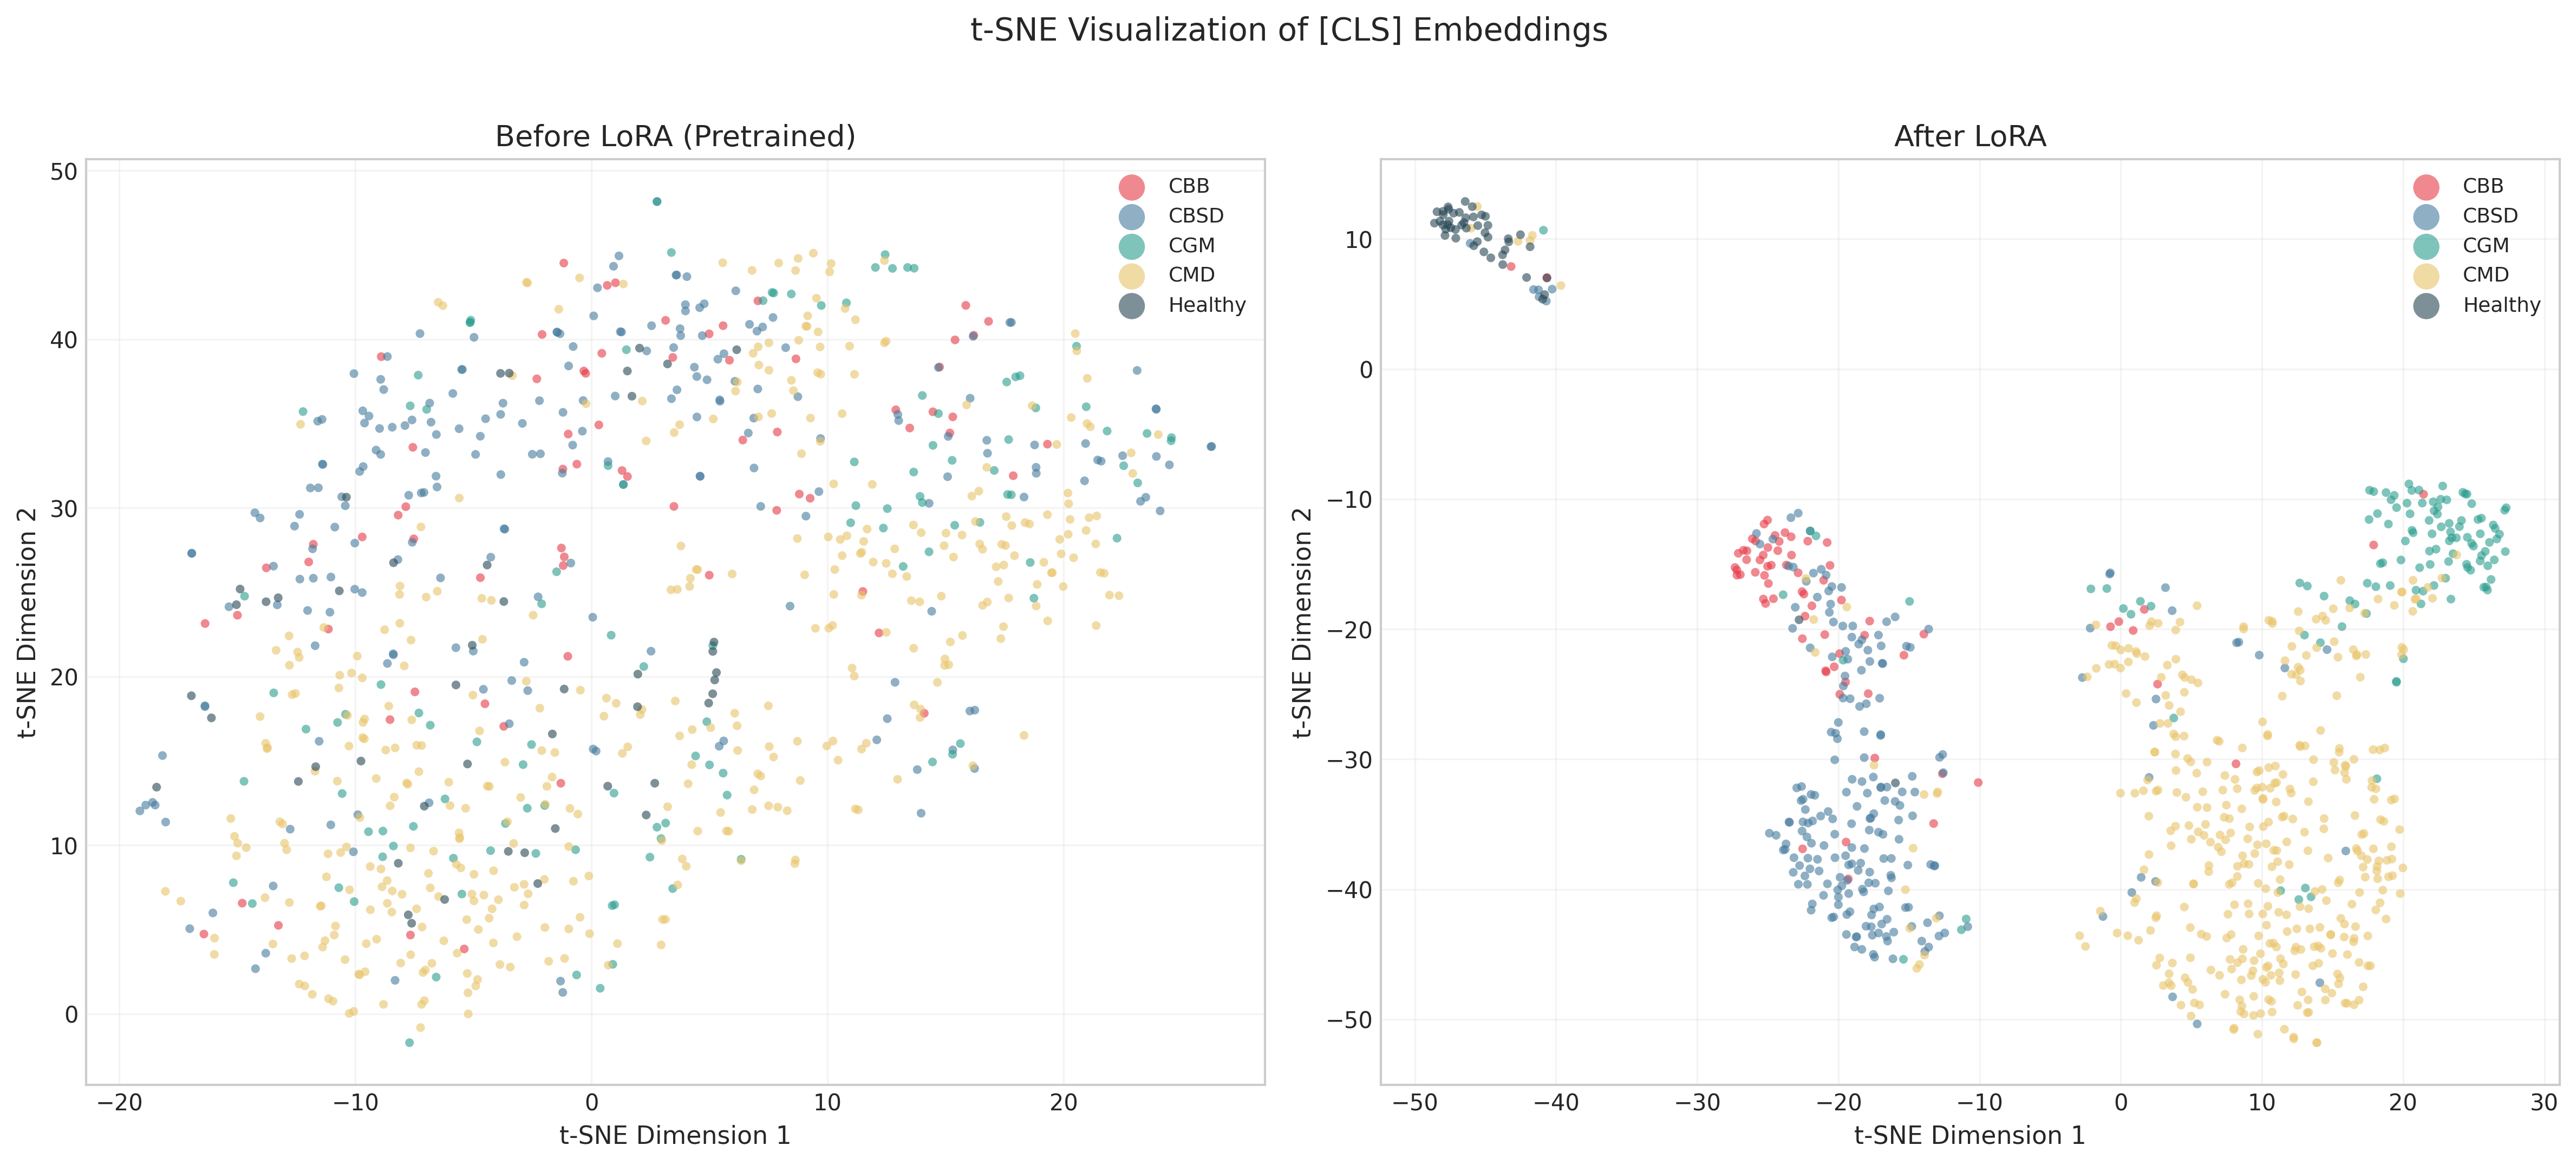


fig_T3_umap_before_after.png:


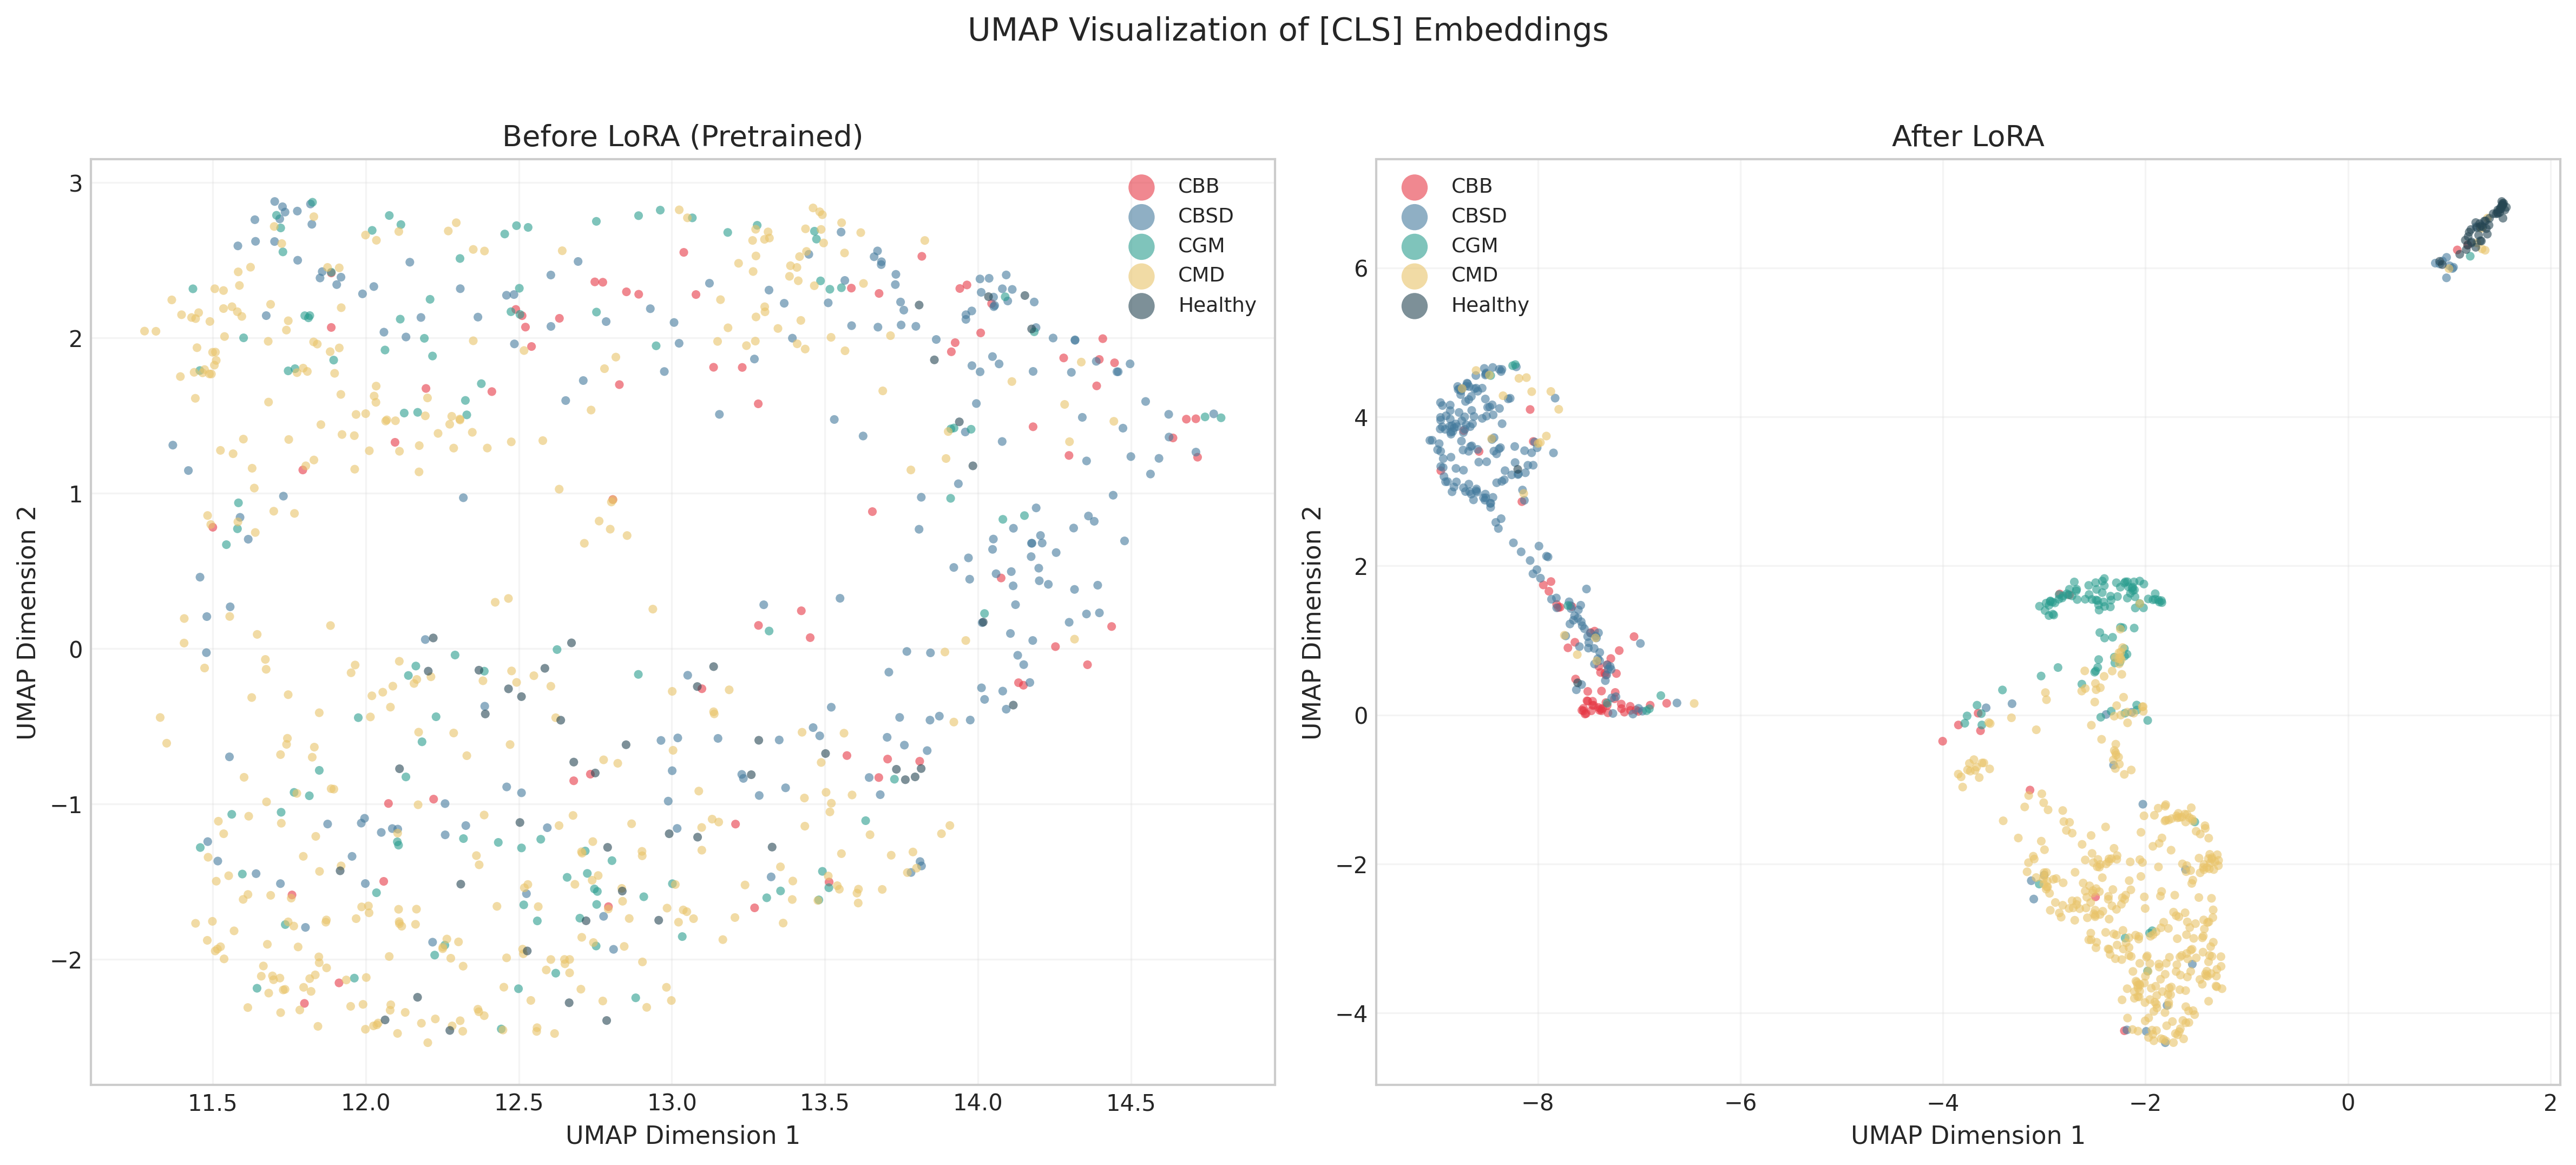

In [6]:
# Clustering metrics
cluster_path = tables_dir / 'clustering_metrics.csv'
if cluster_path.exists():
    cluster_df = pd.read_csv(cluster_path)
    display(cluster_df)

# Correlation
corr_path = tables_dir / 'correlation_shift_vs_accuracy.csv'
if corr_path.exists():
    corr_df = pd.read_csv(corr_path)
    display(corr_df)

# Display T3 figures
for fig_name in ['fig_T3_cls_shift_per_layer.png', 'fig_T3_tsne_before_after.png',
                  'fig_T3_umap_before_after.png', 'fig_T3_correlation_shift_accuracy.png']:
    fig_path = figures_dir / fig_name
    if fig_path.exists():
        print(f'\n{fig_name}:')
        display(IPImage(filename=str(fig_path), width=800))

## Ringkasan

In [7]:
# Load summary report
report_path = Path('./reports/summary_report.md')
if report_path.exists():
    from IPython.display import Markdown
    display(Markdown(report_path.read_text(encoding='utf-8')))
else:
    print('Summary report not yet generated.')

# Summary Report — Pipeline Penelitian LoRA MAE-ViT

> **Status:** Template — akan diperbarui setelah semua eksperimen selesai dijalankan.

---

## Tujuan 1 (T1): Pengaruh LoRA terhadap Performa Klasifikasi

### Ringkasan
Perbandingan performa tiga varian model pada dataset Cassava Leaf Disease Classification:

| Model | Trainable Params | % of Total | Accuracy | Macro F1 | Training Time |
|-------|:-------:|:--------:|:--------:|:--------:|:-------:|
| Linear Probe | — | — | — | — | — |
| Full Fine-tune | — | — | — | — | — |
| LoRA r=4 (Q,V) | — | — | — | — | — |
| LoRA r=8 (Q,V) | — | — | — | — | — |
| LoRA r=16 (Q,V) | — | — | — | — | — |
| LoRA r=32 (Q,V) | — | — | — | — | — |

> **Catatan:** Tabel akan diisi otomatis oleh `src/evaluation/evaluate.py` setelah training selesai.

### Figure References
- `reports/figures/fig_T1_accuracy_vs_params.{png,svg}` — Trade-off accuracy vs parameter trainable
- `reports/figures/fig_T1_f1_comparison.{png,svg}` — Perbandingan F1 score
- `reports/figures/fig_T1_confusion_matrices.{png,svg}` — Grid confusion matrix

---

## Tujuan 2 (T2): Perubahan Struktur Ruang Embedding/Attention akibat LoRA

### Ringkasan
Analisis SVD pada ΔW = B·A menunjukkan:
- **Peluruhan nilai singular:** _(akan diisi)_
- **Effective rank per layer:** _(akan diisi)_
- **Intruder dimensions:** _(akan diisi)_
- **Perubahan entropi attention:** _(akan diisi)_

### Figure References
- `reports/figures/fig_T2_svd_decay_per_layer.{png,svg}` — Kurva peluruhan singular values
- `reports/figures/fig_T2_intruder_dimensions.{png,svg}` — Deteksi intruder dimensions
- `reports/figures/fig_T2_attention_heatmap_comparison.{png,svg}` — Perbandingan attention map
- `reports/figures/fig_T2_attention_entropy.{png,svg}` — Entropi attention per layer

### Table References
- `reports/tables/svd_summary.csv` — Ringkasan SVD per layer

---

## Tujuan 3 (T3): Hubungan Pergeseran Vektor [CLS] dengan Performa

### Ringkasan
Analisis pergeseran [CLS] embedding:
- **Pola shift per layer:** _(delayed specialization — akan diverifikasi)_
- **Silhouette Score:** before LoRA = _, after LoRA = _
- **Davies-Bouldin Index:** before LoRA = _, after LoRA = _
- **Korelasi shift vs akurasi per kelas:** _(akan diisi)_

### Figure References
- `reports/figures/fig_T3_cls_shift_per_layer.{png,svg}` — Cosine shift per layer
- `reports/figures/fig_T3_tsne_before_after.{png,svg}` — t-SNE visualisasi
- `reports/figures/fig_T3_umap_before_after.{png,svg}` — UMAP visualisasi

### Table References
- `reports/tables/clustering_metrics.csv` — Silhouette & DBI sebelum/sesudah
- `reports/tables/correlation_shift_vs_accuracy.csv` — Korelasi statistik

---

## Reproduksi

Untuk mereproduksi hasil penelitian, ikuti urutan perintah di `README.md` atau lihat `plan.md` Section 7.
